## 1. Importing Libraries:

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Loading the 2 datasets
values_df = pd.read_csv('values.csv')
labels_df = pd.read_csv('labels.csv')

In [4]:
# Merging the two datasets
values_df['heart_disease_present'] = labels_df['heart_disease_present']

## 2. Exploratory Data Analysis (EDA):

In [6]:
print("Merged Dataset Head:")
print(values_df.head())

print("\nDataset Info:")
print(values_df.info())

print("\nMissing Values:")
print(values_df.isnull().sum())

Merged Dataset Head:
  patient_id  slope_of_peak_exercise_st_segment               thal  \
0     0z64un                                  1             normal   
1     ryoo3j                                  2             normal   
2     yt1s1x                                  1             normal   
3     l2xjde                                  1  reversible_defect   
4     oyt4ek                                  3  reversible_defect   

   resting_blood_pressure  chest_pain_type  num_major_vessels  \
0                     128                2                  0   
1                     110                3                  0   
2                     125                4                  3   
3                     152                4                  0   
4                     178                1                  0   

   fasting_blood_sugar_gt_120_mg_per_dl  resting_ekg_results  \
0                                     0                    2   
1                                     0

In [7]:
# Statistical summary of numerical columns
print(values_df.describe())

       slope_of_peak_exercise_st_segment  resting_blood_pressure  \
count                         180.000000              180.000000   
mean                            1.550000              131.311111   
std                             0.618838               17.010443   
min                             1.000000               94.000000   
25%                             1.000000              120.000000   
50%                             1.000000              130.000000   
75%                             2.000000              140.000000   
max                             3.000000              180.000000   

       chest_pain_type  num_major_vessels  \
count       180.000000         180.000000   
mean          3.155556           0.694444   
std           0.938454           0.969347   
min           1.000000           0.000000   
25%           3.000000           0.000000   
50%           3.000000           0.000000   
75%           4.000000           1.000000   
max           4.000000     

### Univariate:

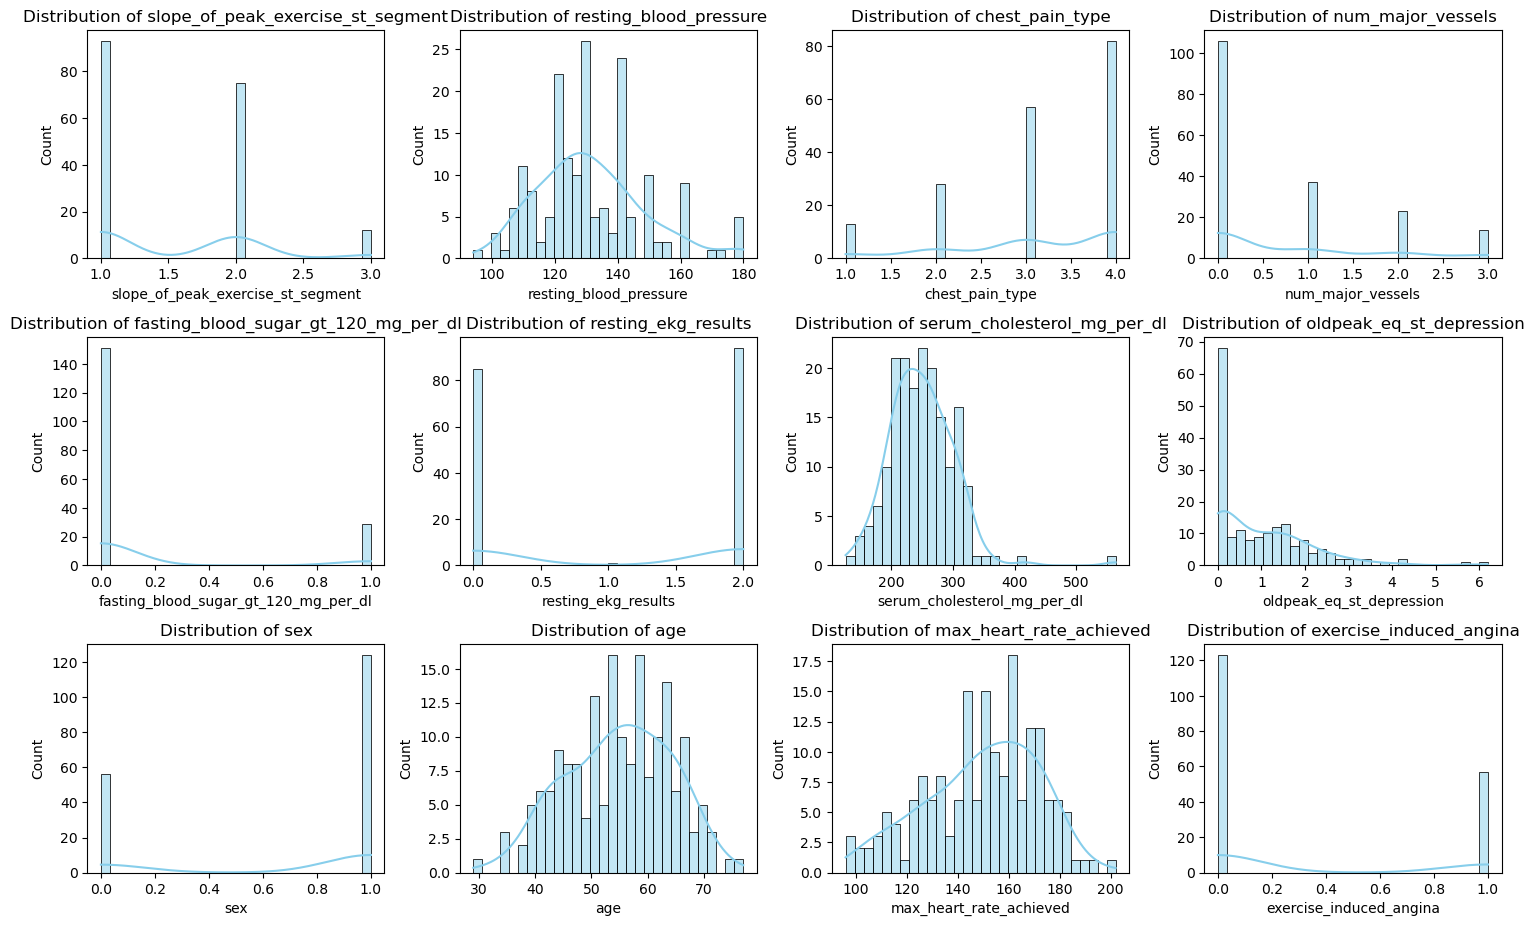

In [9]:
# Distribution of numerical features
numerical_features = values_df.select_dtypes(include=[np.number]).columns.tolist()
numerical_features.remove('heart_disease_present')

plt.figure(figsize=(15, 12))
for i, feature in enumerate(numerical_features):
    plt.subplot(4, 4, i + 1)
    sns.histplot(values_df[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

### Bivariate:

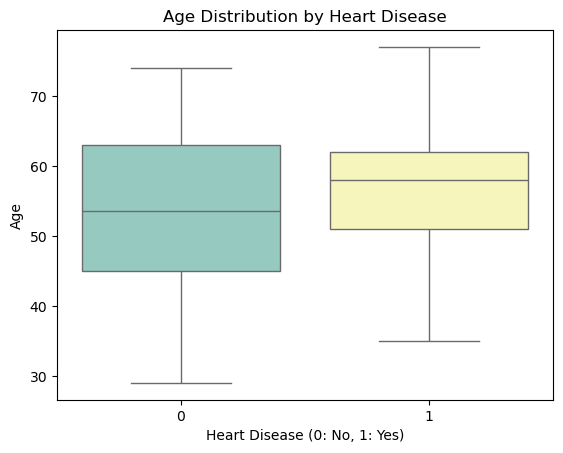

In [11]:
# Relationship between age and target
sns.boxplot(x=values_df['heart_disease_present'], y=values_df['age'], palette='Set3')
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Heart Disease (0: No, 1: Yes)')
plt.ylabel('Age')
plt.show()

### Target Analysis:

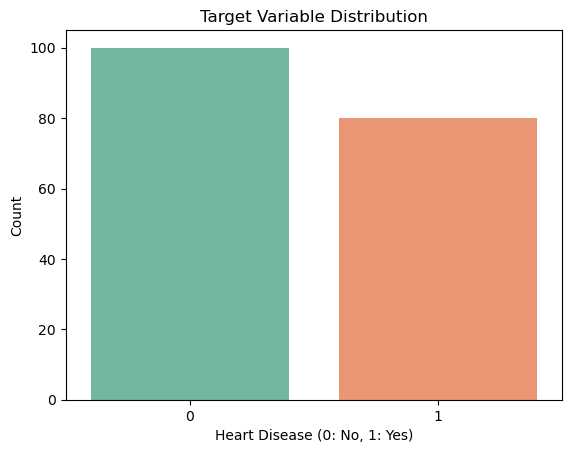

In [13]:
# Target variable distribution
sns.countplot(x=values_df['heart_disease_present'], palette='Set2')
plt.title('Target Variable Distribution')
plt.xlabel('Heart Disease (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

### Categorical Analysis:

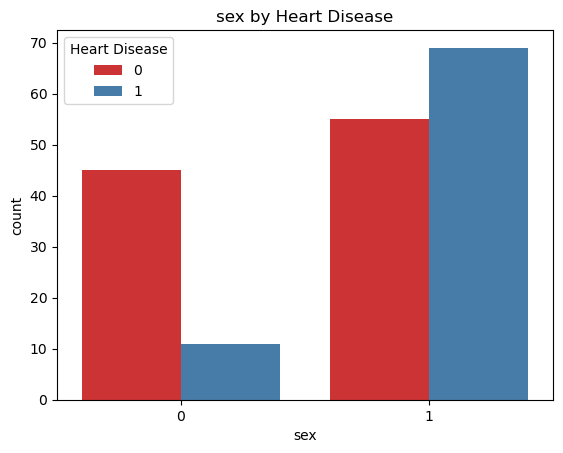

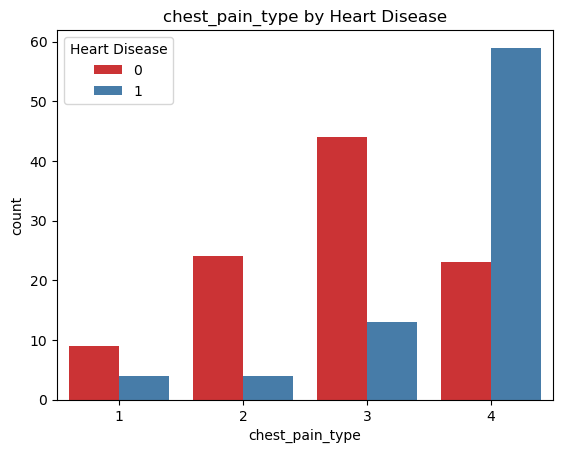

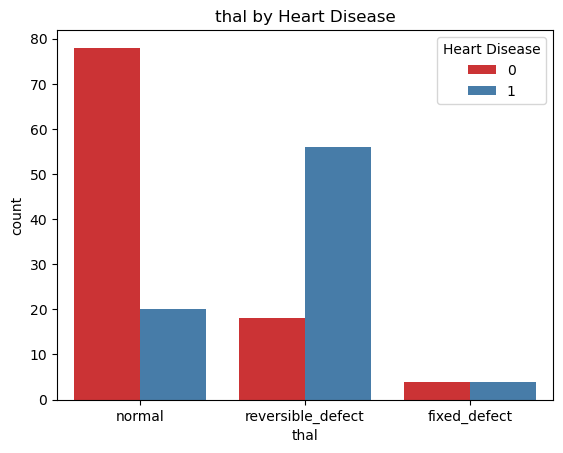

In [15]:
categorical_features = ['sex', 'chest_pain_type', 'thal']  # Adjust based on actual dataset
for feature in categorical_features:
    sns.countplot(x=values_df[feature], hue=values_df['heart_disease_present'], palette='Set1')
    plt.title(f'{feature} by Heart Disease')
    plt.legend(title='Heart Disease')
    plt.show()

### Correlation Heatmap:

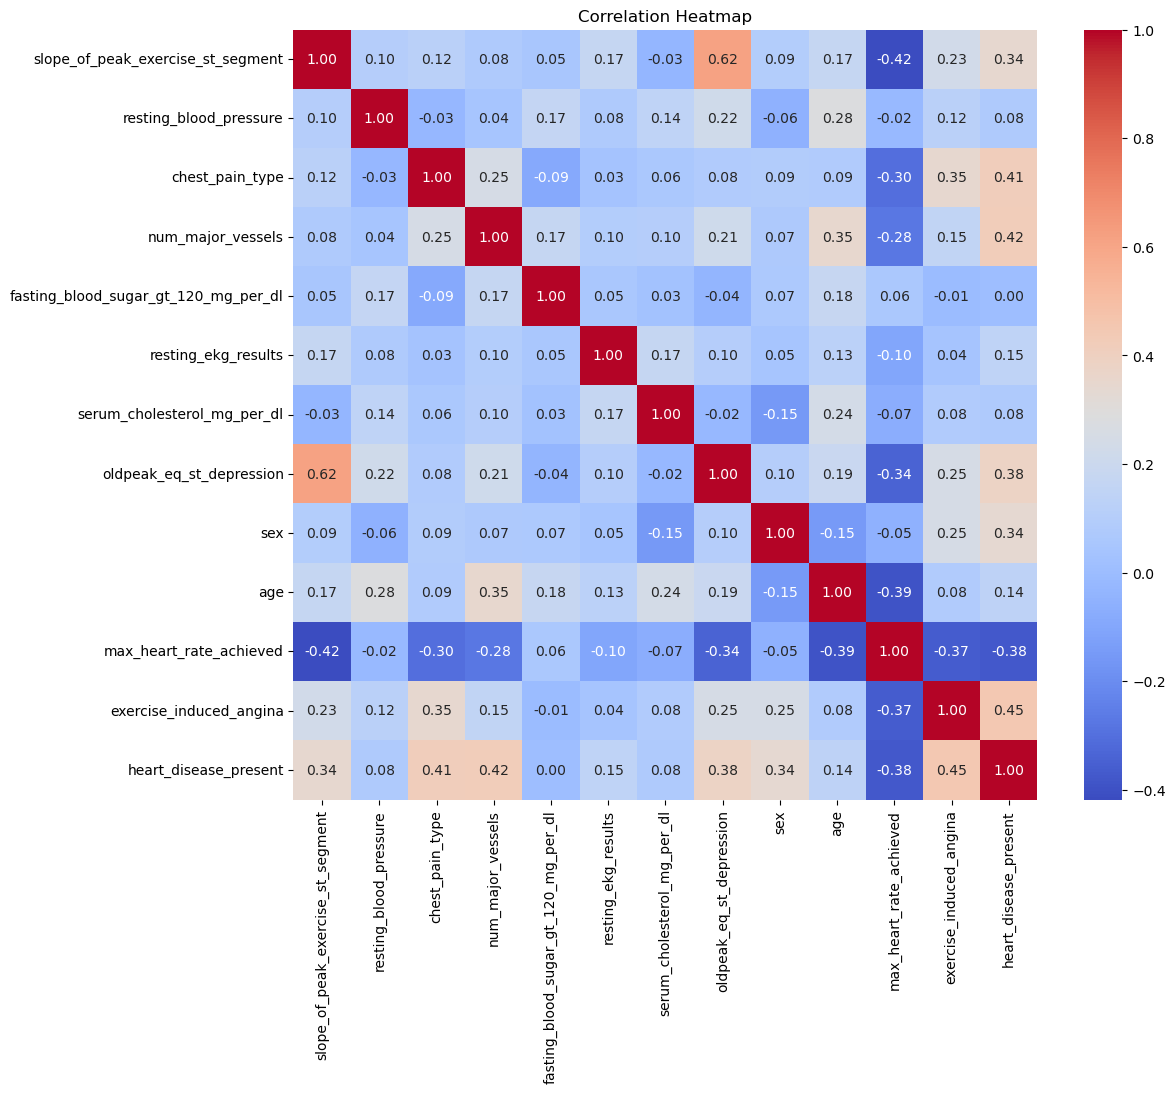

In [17]:
# Select numeric columns only
numeric_df = values_df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 3. Data Preprocessing:

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Encode categorical features
categorical_features = ['thal', 'chest_pain_type']
encoder = LabelEncoder()
for col in categorical_features:
    values_df[col] = encoder.fit_transform(values_df[col])

# Splitting the data into features and target
X = values_df.drop(['patient_id','heart_disease_present'], axis=1)
Y = values_df['heart_disease_present']

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Standardizing the numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4. Model Training and Evaluation:

### (1) Logistic Regression:

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, Y_train)
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]
print("\nLogistic Regression Performance:")
print(classification_report(Y_test, y_pred_log))
print(f"ROC-AUC Score: {roc_auc_score(Y_test, y_prob_log):.2f}")


Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        20
           1       0.78      0.88      0.82        16

    accuracy                           0.83        36
   macro avg       0.83      0.84      0.83        36
weighted avg       0.84      0.83      0.83        36

ROC-AUC Score: 0.94


### (2) Random Forest:

In [24]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, Y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
print("\nRandom Forest Performance:")
print(classification_report(Y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(Y_test, y_prob_rf):.2f}")


Random Forest Performance:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        20
           1       0.84      1.00      0.91        16

    accuracy                           0.92        36
   macro avg       0.92      0.93      0.92        36
weighted avg       0.93      0.92      0.92        36

ROC-AUC Score: 0.96


### (3) Gradient Boosting:

In [26]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, Y_train)
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]
print("\nGradient Boosting Performance:")
print(classification_report(Y_test, y_pred_gb))
print(f"ROC-AUC Score: {roc_auc_score(Y_test, y_prob_gb):.2f}")


Gradient Boosting Performance:
              precision    recall  f1-score   support

           0       0.94      0.80      0.86        20
           1       0.79      0.94      0.86        16

    accuracy                           0.86        36
   macro avg       0.87      0.87      0.86        36
weighted avg       0.87      0.86      0.86        36

ROC-AUC Score: 0.94


### (4) Support Vector Machine:

In [28]:
from sklearn.svm import SVC
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, Y_train)
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]
print("\nSupport Vector Machine Performance:")
print(classification_report(Y_test, y_pred_svm))
print(f"ROC-AUC Score: {roc_auc_score(Y_test, y_prob_svm):.2f}")


Support Vector Machine Performance:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81        20
           1       0.74      0.88      0.80        16

    accuracy                           0.81        36
   macro avg       0.81      0.81      0.81        36
weighted avg       0.82      0.81      0.81        36

ROC-AUC Score: 0.95


## 5. Model Comparison and ROC Curve:

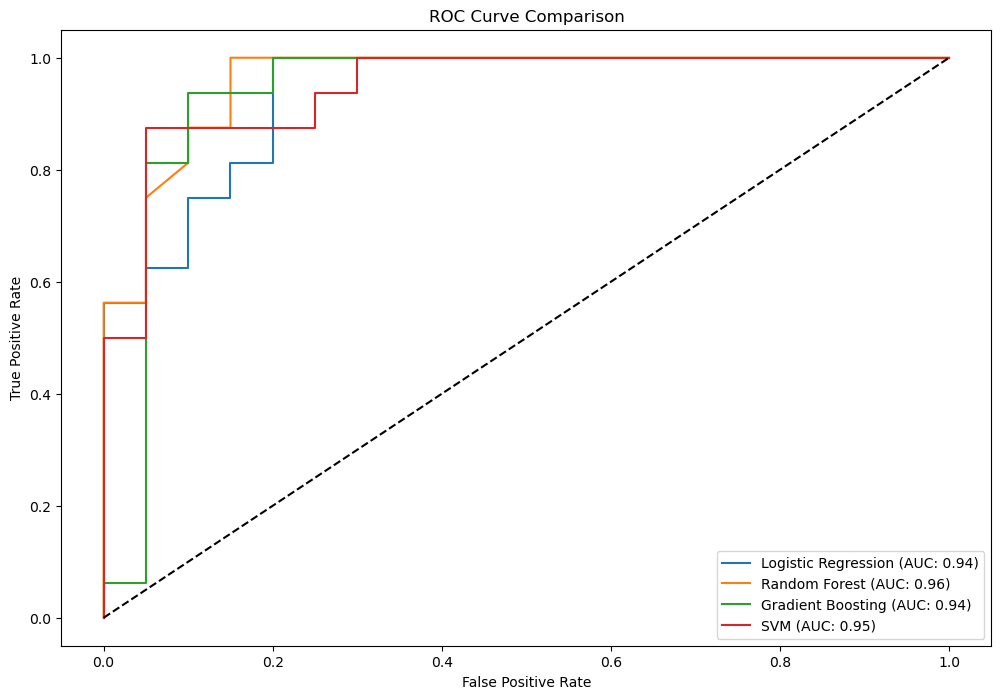

In [30]:
from sklearn.metrics import roc_curve
plt.figure(figsize=(12, 8))
models = {
    "Logistic Regression": y_prob_log,
    "Random Forest": y_prob_rf,
    "Gradient Boosting": y_prob_gb,
    "SVM": y_prob_svm,
}
for name, y_prob in models.items():
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC: {roc_auc_score(Y_test, y_prob):.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## 6. Recommendations:

1. Focus on monitoring patients with abnormal thal results, chest pain types, or high cholesterol levels.
2. Implement a screening program to detect high-risk individuals based on the model's predictions.
3. Use Gradient Boosting or Random Forest (based on AUC scores) for deployment in the hospital's system.
4. Train healthcare staff to interpret model results and act on high-risk predictions.